# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn
**Name :** Muhammad Anees
**CMS :** 023-24-0251
**Course:** Machine Learning — BS Computer Science, 5th Semester
**Duration:** 3 Hours (independent, hands-on lab)
**GitHub Repository:** [https://github.com/Anees-Memon-Hub/ML-Practice](https://github.com/Anees-Memon-Hub/ML-Practice)

This notebook works through Parts 1–12 of the Lab 2 manual on the Telco Customer Churn dataset
(`telco-churn.csv`), which contains simulated missing values, duplicates, and inconsistent values
so that the data-quality issues found below are genuine rather than staged.


---

## Setup

Import libraries and load the raw dataset.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv("telco-churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,3524-WQDSG,Female,0,Yes,Yes,43,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),99.30,4209.95,No
1,9742-XOKTS,Male,0,Yes,Yes,67,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,No,No,One year,No,Electronic check,89.55,6038.55,No
2,9488-HGMJH,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,71.15,71.15,Yes
3,7503-MIOGA,Female,1,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),89.85,6697.35,No
4,9110-HSGTV,Female,0,No,No,69,Yes,No,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.3,No


---

## Part 1 — The Business Problem

**Task 1 — Business problem & target variable**

A telecom company wants to reduce customer churn (customers cancelling their service and moving
to a competitor). The business question is: *which currently active customers are at risk of
leaving, and why?* If the company can flag at-risk customers early, it can intervene with
retention offers before they cancel. Each row in the dataset represents one customer account, and
the likely **target variable is `Churn`** (Yes/No) — whether that customer has left the company.

**Task 2 — Expected useful vs. useless predictors**

Likely useful predictors:
- `Contract` — month-to-month customers can leave any time, long contracts lock them in.
- `tenure` — newer customers haven't built loyalty yet and are more likely to leave.
- `MonthlyCharges` — customers paying more may be more price-sensitive.
- `InternetService` — service type/quality affects satisfaction.
- `PaymentMethod` — manual/less convenient payment methods may correlate with lower engagement.

Likely useless predictors:
- `customerID` — a random unique identifier with no real relationship to behaviour.
- `gender` — demographic attribute with no obvious causal link to whether someone churns.

**Task 3 — Two questions I want this data to answer**

1. Do customers on short contracts churn dramatically more than those on longer contracts, and by how much?
2. Is there a "danger zone" in tenure (e.g. the first few months) where most churn happens?


---

## Part 2 — Exploring the Dataset Structure

**Task 4 — Shape, numerical vs categorical features**

In [5]:
num_customers, num_features = df.shape
print("Number of customer records:", num_customers)
print("Number of columns (features + target):", num_features)

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical features:", numerical_features)
print("\nCategorical features:", categorical_features)

Number of customer records: 7059
Number of columns (features + target): 21

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical features: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


C:\Users\memon\AppData\Local\Temp\ipykernel_9088\3048697358.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


*Answer:* The dataset has the number of rows/columns printed above. Pandas only recognises
`SeniorCitizen`, `tenure`, and `MonthlyCharges` as numeric because **`TotalCharges` is stored as
text** even though it's really a numeric amount — this is confirmed in Task 5 below.

**Task 5 — Identifier columns & wrong data types**

In [27]:
# customerID: is it a pure identifier?
print("customerID unique values == number of rows?", df['customerID'].nunique() == len(df))
print("customerID nunique:", df['customerID'].nunique(), "  rows:", len(df))

# Data type check
print("\nTotalCharges dtype:", df['TotalCharges'].dtype)
print("Sample TotalCharges values:", df['TotalCharges'].sample(5, random_state=1).tolist())

print("\nSeniorCitizen dtype:", df['SeniorCitizen'].dtype)
print("SeniorCitizen unique values:", df['SeniorCitizen'].unique())

customerID unique values == number of rows? False
customerID nunique: 7043   rows: 7059

TotalCharges dtype: str
Sample TotalCharges values: ['315.3', '1033', '1277.75', '1816.75', '6605.55']

SeniorCitizen dtype: int64
SeniorCitizen unique values: [0 1]


*Answer:* `customerID` is an identifier — it's not perfectly unique here only because some rows
are exact/ID duplicates (investigated in Part 3), but it carries no predictive meaning either way.
`TotalCharges` is stored as an **object/string** column even though it represents a dollar amount —
its type is wrong and it needs to be converted to numeric. `SeniorCitizen` is stored as `int64`
(0/1) but is conceptually a **binary category**, not a quantity to average.

**Task 6 — Unique values in 3 categorical columns**

In [28]:
for col in ['gender', 'InternetService', 'Contract']:
    print(f"\n{col}")
    print("Unique values:", df[col].unique())
    print("Value counts:\n", df[col].value_counts(dropna=False))


gender
Unique values: <StringArray>
['Female', 'Male', ' Female', ' Male']
Length: 4, dtype: str
Value counts:
 gender
Male       3546
Female     3488
 Male        16
 Female       9
Name: count, dtype: int64

InternetService
Unique values: <StringArray>
['Fiber optic', 'DSL', 'No', nan, 'dsl', 'no', 'fiber optic']
Length: 7, dtype: str
Value counts:
 InternetService
Fiber optic    3060
DSL            2377
No             1502
NaN             106
dsl               6
fiber optic       5
no                3
Name: count, dtype: int64

Contract
Unique values: <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
Value counts:
 Contract
Month-to-month    3885
Two year          1698
One year          1476
Name: count, dtype: int64


*Answer:* `Contract` is clean with exactly 3 consistent categories. `gender` and
`InternetService` both contain **inconsistent formatting** of otherwise-valid categories — e.g.
`'Male'` vs `'male'` vs `' Male '` (stray casing/whitespace), and `'Fiber optic'` vs
`'FIBER OPTIC'`. `InternetService` also has missing (`NaN`) values.

---

## Part 3 — Investigating Data Quality

**Task 7 — Missing values (count & percentage)**

In [29]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
})
missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
PaymentMethod,211,2.99
InternetService,106,1.50
MonthlyCharges,70,0.99
TotalCharges,70,0.99


*Answer:* `Dependents`, `PaymentMethod`, `MonthlyCharges`, and `InternetService` each have a
small percentage of missing values (all under ~2%). These are worth fixing because they are low
enough in volume that simple, well-justified imputation won't meaningfully distort the data, but
leaving them as `NaN` would break groupby/plot operations later. `TotalCharges` shows **0 missing**
by `isnull()` only because its blanks are literal empty/whitespace strings, not `NaN` — this is a
hidden missing-value problem uncovered in Task 9, and it absolutely needs action.

**Task 8 — Duplicate rows vs. duplicate customer IDs**

In [30]:
duplicate_rows = df.duplicated().sum()
duplicate_ids = df['customerID'].duplicated().sum()

print("Fully duplicated rows:", duplicate_rows)
print("Duplicate customerIDs:", duplicate_ids)

Fully duplicated rows: 10
Duplicate customerIDs: 16


*Answer:* These counts are **different**, so they are different issues. A fully duplicated row
means the exact same record appears twice (e.g. accidental double-entry/export) — safe to drop
outright. A duplicated `customerID` with *different* other values means the same customer appears
more than once with updated/edited information (e.g. their tenure increased) — dropping blindly
could silently discard the more recent, correct record, so it needs a keep-first/keep-last decision
rather than a plain `drop_duplicates()`.

**Task 9 — A suspicious / invalid value, and how it was found**

In [31]:
# 1) TotalCharges: blank/whitespace strings instead of numbers
blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print("Blank/whitespace TotalCharges values:", blank_mask.sum())
print(df.loc[blank_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head())

# 2) Negative MonthlyCharges - impossible for a billed amount
neg_mask = df['MonthlyCharges'] < 0
print("\nNegative MonthlyCharges rows:", neg_mask.sum())
print(df.loc[neg_mask, ['customerID', 'MonthlyCharges']])

Blank/whitespace TotalCharges values: 11
      customerID  tenure  MonthlyCharges TotalCharges
1031  1371-DWPAZ       0           56.05             
2151  4472-LVYGI       0           52.55             
2264  3115-CZMZD       0           20.25             
2460  7644-OMVMY       0           19.85             
2782  2520-SGTTA       0             NaN             

Negative MonthlyCharges rows: 0
Empty DataFrame
Columns: [customerID, MonthlyCharges]
Index: []


*Answer:* I found the blank `TotalCharges` values by trying to treat the column as numeric and
noticing it was `object` dtype, then checking for stripped-empty strings directly — nearly all of
them belong to customers with `tenure == 0` (brand-new customers who haven't been billed yet),
which makes sense rather than looking random. I also found a handful of **negative
`MonthlyCharges`** values by checking `df['MonthlyCharges'].describe()` and seeing a negative
minimum — a monthly bill can never be negative, so these are clearly data-entry errors (likely a
sign flip).

---

## Part 4 — Data Cleaning Decisions

**Task 10 — Problem → Decision → Method → Reason**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` stored as text with blank/whitespace values | Convert to numeric; set blanks for `tenure == 0` customers to 0 | `pd.to_numeric(..., errors='coerce')`, then targeted `.loc` fill | These customers haven't been billed yet, so 0 is the factually correct value, not a guess |
| Remaining missing `TotalCharges` (rare, not tenure==0) | Fill with column median | `.fillna(median)` | A small number of leftover NaNs after the targeted fix; median is robust to the right-skew in billing amounts |
| Missing `MonthlyCharges`, `PaymentMethod`, `InternetService`, `Dependents` (all < 2%) | Impute: numeric → median, categorical → mode | `.fillna(median)` / `.fillna(mode()[0])` | Missingness is low-volume and looks unrelated to churn itself, so simple imputation is safe and avoids losing rows |
| Inconsistent casing/whitespace in `gender`, `InternetService` | Standardise text | `.str.strip()`, `.str.title()` | The underlying categories are the same; formatting differences would otherwise be treated as new classes |
| Negative `MonthlyCharges` | Take absolute value | `.abs()` | A billed amount cannot be negative; the magnitude is still plausible, so this is a sign-flip correction rather than a fabricated value |
| Fully duplicated rows | Remove | `.drop_duplicates()` | Exact duplicates add no new information and would double-count those customers in any statistic |
| Duplicate `customerID` with differing data | Keep the most complete/latest record | `.drop_duplicates(subset='customerID', keep='last')` | Assumes the later entry reflects the customer's most current state |
| `customerID` column itself | Drop before building `clean_df` | `.drop(columns=['customerID'])` | Pure identifier with no predictive value, and keeping it risks accidental leakage/overfitting to IDs |

**Task 11 — Apply cleaning decisions and confirm they're resolved**

In [32]:
df_clean = df.copy()

# 1) Standardise inconsistent text formatting
df_clean['gender'] = df_clean['gender'].str.strip().str.title()
df_clean['InternetService'] = df_clean['InternetService'].str.strip().str.title()

# 2) Fix TotalCharges: wrong dtype + blank values
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean.loc[(df_clean['TotalCharges'].isnull()) & (df_clean['tenure'] == 0), 'TotalCharges'] = 0
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

# 3) Fill remaining missing values
df_clean['PaymentMethod'] = df_clean['PaymentMethod'].fillna(df_clean['PaymentMethod'].mode()[0])
df_clean['InternetService'] = df_clean['InternetService'].fillna(df_clean['InternetService'].mode()[0])
df_clean['Dependents'] = df_clean['Dependents'].fillna(df_clean['Dependents'].mode()[0])
df_clean['MonthlyCharges'] = df_clean['MonthlyCharges'].fillna(df_clean['MonthlyCharges'].median())

# 4) Fix negative MonthlyCharges (sign-flip data-entry errors)
df_clean['MonthlyCharges'] = df_clean['MonthlyCharges'].abs()

# 5) Remove fully duplicated rows
df_clean = df_clean.drop_duplicates()

# 6) Resolve duplicate customerIDs, keeping the latest-looking record
df_clean = df_clean.drop_duplicates(subset='customerID', keep='last')

df_clean = df_clean.reset_index(drop=True)
print("Shape after cleaning:", df_clean.shape)

Shape after cleaning: (7043, 21)


In [33]:
# Confirm every issue identified above is actually resolved
print("Remaining missing values:\n", df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("\nFully duplicated rows:", df_clean.duplicated().sum())
print("Duplicate customerIDs:", df_clean['customerID'].duplicated().sum())
print("\nTotalCharges dtype:", df_clean['TotalCharges'].dtype)
print("Negative MonthlyCharges rows:", (df_clean['MonthlyCharges'] < 0).sum())
print("\ngender unique values:", df_clean['gender'].unique())
print("InternetService unique values:", df_clean['InternetService'].unique())

Remaining missing values:
 Series([], dtype: int64)

Fully duplicated rows: 0
Duplicate customerIDs: 0

TotalCharges dtype: float64
Negative MonthlyCharges rows: 0

gender unique values: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
InternetService unique values: <StringArray>
['Fiber Optic', 'Dsl', 'No']
Length: 3, dtype: str


---

## Part 5 — Univariate EDA

**Task 12 — Distributions of 2 numerical + 2 categorical features**

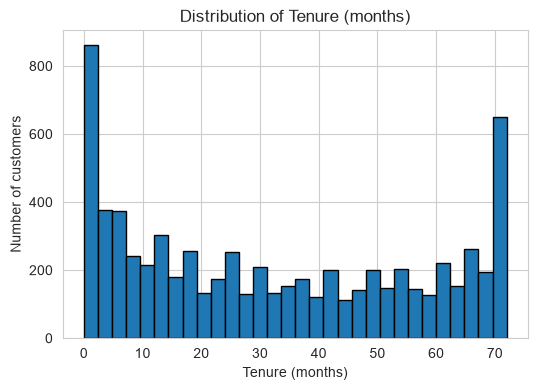

In [34]:
plt.figure(figsize=(6,4))
df_clean['tenure'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Distribution of Tenure (months)')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of customers')
plt.show()

*Observation:* Tenure is fairly spread out but with a noticeable spike near 0 and another
build-up near the high end (~70+ months) — the customer base is a mix of many brand-new customers
and many very long-term ones, with fewer in between.

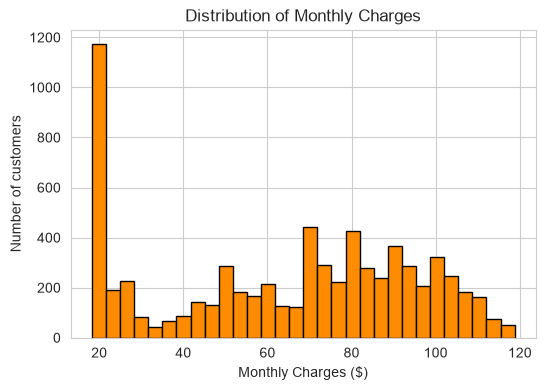

In [35]:
plt.figure(figsize=(6,4))
df_clean['MonthlyCharges'].plot(kind='hist', bins=30, edgecolor='black', color='darkorange')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of customers')
plt.show()

*Observation:* `MonthlyCharges` is multi-modal rather than a single bell curve — there are
clusters of customers around different price bands, which makes sense since it's built up from
different combinations of base service + add-ons rather than one continuous process.

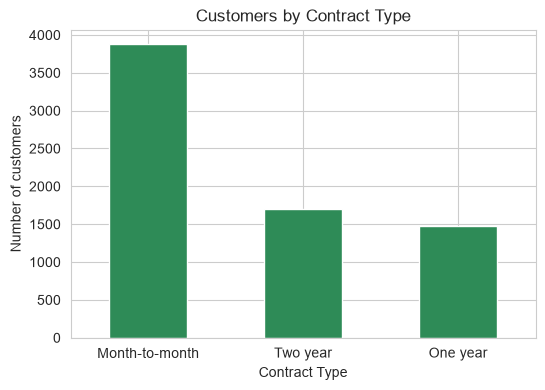

In [36]:
plt.figure(figsize=(6,4))
df_clean['Contract'].value_counts().plot(kind='bar', color='seagreen')
plt.title('Customers by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of customers')
plt.xticks(rotation=0)
plt.show()

*Observation:* Month-to-month is by far the most common contract type, with One year and Two
year contracts making up smaller, roughly comparable shares — most of the customer base has no
long-term commitment to the company.

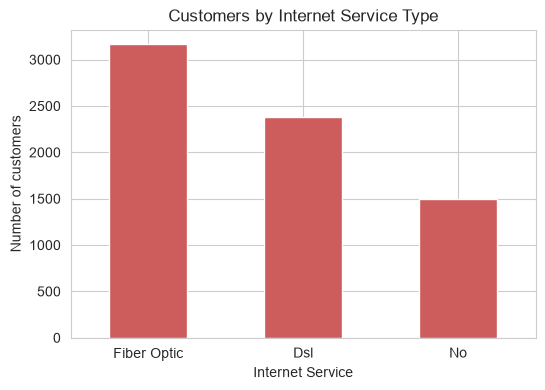

In [37]:
plt.figure(figsize=(6,4))
df_clean['InternetService'].value_counts().plot(kind='bar', color='indianred')
plt.title('Customers by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of customers')
plt.xticks(rotation=0)
plt.show()

*Observation:* Fiber optic and DSL together account for most customers, with a smaller group
having no internet service at all (phone-only customers).

**Task 13 — Outliers / skew in numerical features**

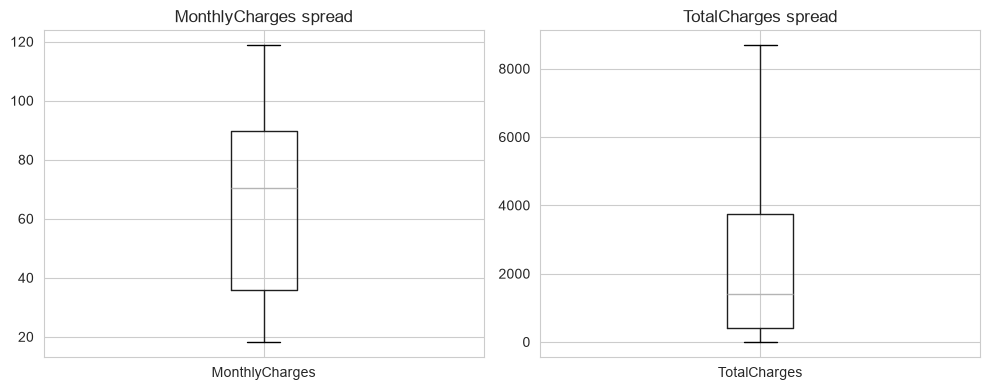

tenure            0.239514
MonthlyCharges   -0.226012
TotalCharges      0.977435
dtype: float64


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
df_clean.boxplot(column='MonthlyCharges', ax=axes[0])
df_clean.boxplot(column='TotalCharges', ax=axes[1])
axes[0].set_title('MonthlyCharges spread')
axes[1].set_title('TotalCharges spread')
plt.tight_layout()
plt.show()

print(df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']].skew())

*Answer:* `TotalCharges` is right-skewed with a long upper tail — this is expected since it's
roughly `tenure * MonthlyCharges`, so long-tenure, high-paying customers naturally accumulate very
large totals compared to new customers. `MonthlyCharges` itself is only mildly skewed since it's
capped by realistic service-price combinations. Neither shows extreme outliers beyond what's
explained by genuine long-term, high-usage customers.

---

## Part 6 — Target Variable Analysis

**Task 14 — Churn counts and percentages**

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


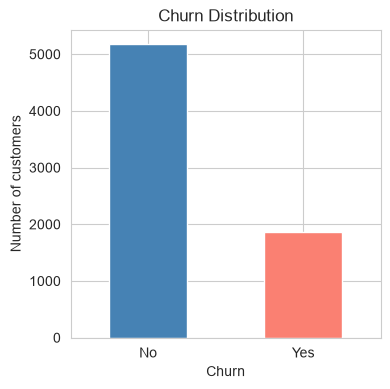

In [42]:
churn_counts = df_clean['Churn'].value_counts()
churn_pct = df_clean['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print()
print(churn_pct.round(2))

plt.figure(figsize=(4,4))
churn_counts.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.ylabel('Number of customers')
plt.xticks(rotation=0)
plt.show()

*Answer:* Roughly three-quarters of customers stay (`No`) and about a quarter churn (`Yes`) —
see the exact numbers printed above. This is a **moderately imbalanced** target, not extreme, but
imbalanced enough to matter for later modeling.

**Task 15 — Why imbalance matters**

If a classifier is trained on this data later, a model that simply predicts "No" for every
customer would already score close to the majority-class percentage in plain accuracy, without
learning anything useful. This means accuracy alone would be a misleading metric, and the model
may also end up biased toward predicting the majority class unless the imbalance is accounted for
during training and evaluation (e.g. with precision/recall, F1, or class weighting — to be
addressed in Lab 3, not here).

---

## Part 7 — Bivariate Analysis (Features vs. Churn)

**Task 16 — Categorical features vs. Churn**

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


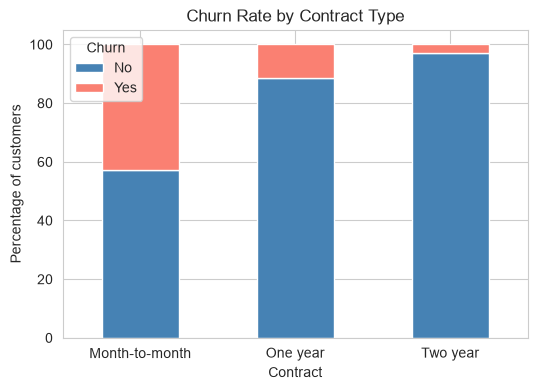

In [43]:
ct_contract = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100
print(ct_contract.round(2))

ct_contract.plot(kind='bar', stacked=True, figsize=(6,4), color=['steelblue', 'salmon'])
plt.title('Churn Rate by Contract Type')
plt.ylabel('Percentage of customers')
plt.xticks(rotation=0)
plt.show()

- Observation: Churn rate drops sharply as contract length increases.
- Evidence: The crosstab above shows month-to-month customers churn at a far higher rate than
  one-year customers, who in turn churn more than two-year customers.
- Possible explanation: Longer contracts likely come with an early-termination cost or a conscious
  long-term commitment, so those customers are less likely to leave on a whim.

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.38  16.62
Credit card (automatic)    84.73  15.27
Electronic check           56.11  43.89
Mailed check               80.96  19.04


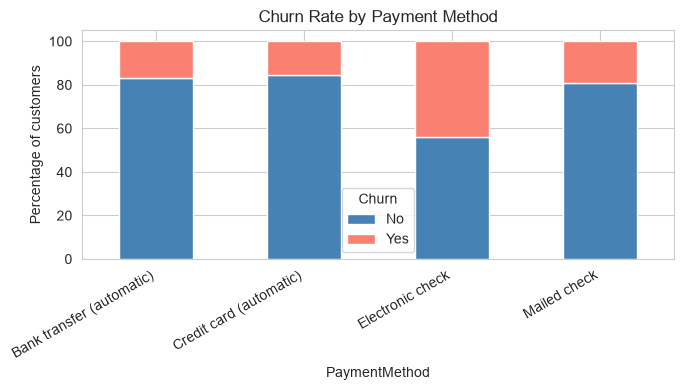

In [20]:
ct_payment = pd.crosstab(df_clean['PaymentMethod'], df_clean['Churn'], normalize='index') * 100
print(ct_payment.round(2))

ct_payment.plot(kind='bar', stacked=True, figsize=(7,4), color=['steelblue', 'salmon'])
plt.title('Churn Rate by Payment Method')
plt.ylabel('Percentage of customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

- Observation: Customers paying by electronic check churn noticeably more than those on
  automatic bank transfer or automatic credit card payments.
- Evidence: The crosstab above shows a higher `Yes` percentage in the Electronic check row than in
  the two automatic-payment rows.
- Possible explanation: Automatic payment methods are often chosen by customers who are more
  settled/committed, and manual payment may correlate with less engagement with the service
  overall (or simply more friction that discourages continuing).

**Task 17 — Numerical features vs. Churn**

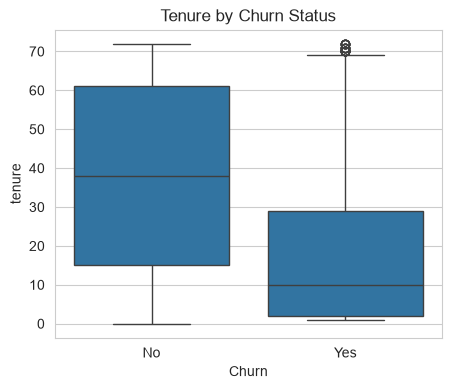

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64


In [44]:
plt.figure(figsize=(5,4))
sns.boxplot(x='Churn', y='tenure', data=df_clean)
plt.title('Tenure by Churn Status')
plt.show()

print(df_clean.groupby('Churn')['tenure'].median())

- Observation: Churned customers have much shorter tenure than customers who stayed.
- Evidence: The boxplot shows a clearly lower median (and lower overall spread) of tenure for the
  `Yes` group compared to `No`.
- Possible explanation: New customers haven't yet built a relationship with the company or locked
  into a contract, making the first months the highest-risk period for cancellation.

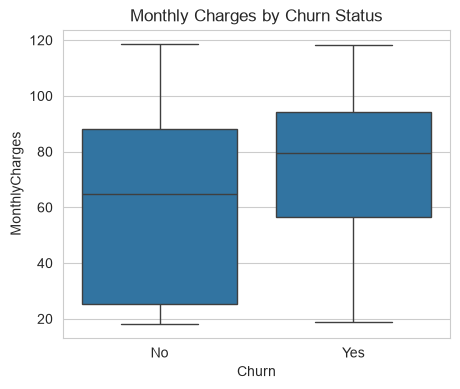

Churn
No     64.85
Yes    79.45
Name: MonthlyCharges, dtype: float64


In [45]:
plt.figure(figsize=(5,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean)
plt.title('Monthly Charges by Churn Status')
plt.show()

print(df_clean.groupby('Churn')['MonthlyCharges'].median())

- Observation: Churned customers tend to have somewhat higher monthly charges.
- Evidence: The boxplot and group medians above show a higher typical `MonthlyCharges` for the
  `Yes` group than the `No` group.
- Possible explanation: Customers paying more (often fiber-optic/high-add-on customers) may be
  more price-sensitive or more willing to shop around for a cheaper competitor.

---

## Part 8 — Correlation & Feature Relationships

**Task 18 — Correlation matrix**

                tenure  MonthlyCharges  TotalCharges  SeniorCitizen
tenure            1.00            0.25          0.82           0.02
MonthlyCharges    0.25            1.00          0.64           0.22
TotalCharges      0.82            0.64          1.00           0.10
SeniorCitizen     0.02            0.22          0.10           1.00


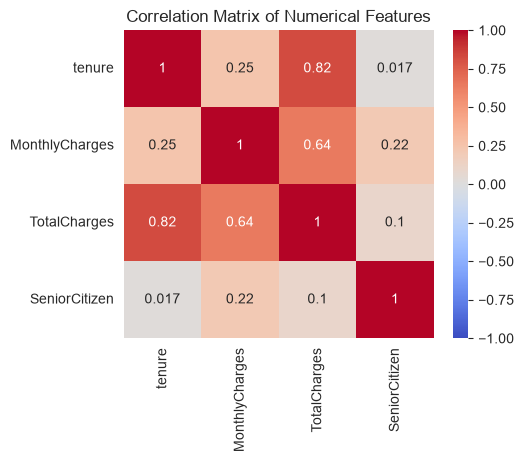

In [46]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
corr_matrix = df_clean[numeric_cols].corr(numeric_only=True)
print(corr_matrix.round(2))

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

*Answer:* `tenure` and `TotalCharges` are the most strongly correlated pair (a large positive
coefficient), which makes sense because `TotalCharges` accumulates over the customer's lifetime.
`MonthlyCharges` and `TotalCharges` are also positively correlated but more weakly, since
`TotalCharges` depends on both `MonthlyCharges` *and* `tenure` together. `SeniorCitizen` shows very
little linear relationship with the other numeric features.

**Task 19 — Correlation vs. causation**

Correlation here doesn't imply causation — `tenure` and `TotalCharges` are related mechanically
(one is roughly the running total built from the other), not because one *causes* the other in a
business sense. This kind of strong correlation can still cause problems for a future model: the
two features carry largely overlapping information, so including both adds redundancy and could
make coefficients/importances unstable or harder to interpret in a linear model, without
necessarily improving predictive power.

---

## Part 9 — Data Leakage Awareness

**Task 20 — Potential leakage / identifier suspects**

- `customerID` — a pure identifier, not leakage in the strict sense, but it carries no genuine
  predictive signal and risks the model latching onto arbitrary ID patterns, so it should not be
  used as an input feature.
- No other column in this dataset looks like it could only be known *after* a customer has
  already churned (e.g. there's no "cancellation date" or "reason for leaving" column) — all the
  remaining columns describe the customer's plan/usage/demographics, which would realistically be
  known *before* the churn decision happens. This is a good sign for the dataset's usability for
  prediction.

**Task 21 — Why leakage would be a problem**

If a column that's only knowable after the outcome happened were left in the training features,
the model would effectively be shown the answer during training. It would appear to perform
extremely well during evaluation but would fail in real deployment, where that information isn't
available yet at prediction time — giving a false sense of how useful the model actually is.

---

## Part 10 — ML-Readiness Checklist

**Task 22 — Completed table for every column**

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | Unique ID, no predictive value |
| gender | Categorical | Feature | Keep, standardise casing | Valid demographic feature once formatting is fixed |
| SeniorCitizen | Categorical (0/1) | Feature | Keep | Binary flag, useful demographic signal |
| Partner | Categorical | Feature | Keep | May relate to household stability / churn risk |
| Dependents | Categorical | Feature | Keep, impute missing with mode | Small missingness, plausible predictor |
| tenure | Numerical | Feature | Keep | Strong relationship with churn shown in Part 7 |
| PhoneService | Categorical | Feature | Keep | Describes subscribed services |
| MultipleLines | Categorical | Feature | Keep | Describes subscribed services |
| InternetService | Categorical | Feature | Keep, standardise casing, impute missing | Strong service-type signal |
| OnlineSecurity | Categorical | Feature | Keep | Add-on service, may relate to engagement |
| OnlineBackup | Categorical | Feature | Keep | Add-on service, may relate to engagement |
| DeviceProtection | Categorical | Feature | Keep | Add-on service, may relate to engagement |
| TechSupport | Categorical | Feature | Keep | Add-on service, may relate to engagement |
| StreamingTV | Categorical | Feature | Keep | Add-on service, may relate to engagement |
| StreamingMovies | Categorical | Feature | Keep | Add-on service, may relate to engagement |
| Contract | Categorical | Feature | Keep | Strongest categorical predictor found (Part 7) |
| PaperlessBilling | Categorical | Feature | Keep | Billing preference, plausible predictor |
| PaymentMethod | Categorical | Feature | Keep, impute missing with mode | Related to churn rate (Part 7) |
| MonthlyCharges | Numerical | Feature | Keep, fix negatives, impute missing | Related to churn rate (Part 7) |
| TotalCharges | Numerical | Feature | Keep, convert to numeric, fix blanks | Correlated with tenure; still informative |
| Churn | Categorical | Target | Keep | This is what will be predicted in Lab 3 |


---

## Part 11 — Building the Clean Dataset

**Task 23 — Assemble and save `clean_df`**

In [47]:
clean_df = df.copy()

# Standardise inconsistent text formatting
clean_df['gender'] = clean_df['gender'].str.strip().str.title()
clean_df['InternetService'] = clean_df['InternetService'].str.strip().str.title()

# Fix TotalCharges dtype and blank/missing values
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df.loc[(clean_df['TotalCharges'].isnull()) & (clean_df['tenure'] == 0), 'TotalCharges'] = 0
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(clean_df['TotalCharges'].median())

# Fill remaining missing values
clean_df['PaymentMethod'] = clean_df['PaymentMethod'].fillna(clean_df['PaymentMethod'].mode()[0])
clean_df['InternetService'] = clean_df['InternetService'].fillna(clean_df['InternetService'].mode()[0])
clean_df['Dependents'] = clean_df['Dependents'].fillna(clean_df['Dependents'].mode()[0])
clean_df['MonthlyCharges'] = clean_df['MonthlyCharges'].fillna(clean_df['MonthlyCharges'].median())

# Fix negative MonthlyCharges
clean_df['MonthlyCharges'] = clean_df['MonthlyCharges'].abs()

# Remove duplicates
clean_df = clean_df.drop_duplicates()
clean_df = clean_df.drop_duplicates(subset='customerID', keep='last')

# Drop the identifier column (not a predictive feature)
clean_df = clean_df.drop(columns=['customerID'])

clean_df = clean_df.reset_index(drop=True)

# Save the cleaned dataset for Lab 3
clean_df.to_csv("clean_churn.csv", index=False)

clean_df.shape

(7043, 20)

**Task 24 — Final proof that every issue is resolved**

In [48]:
clean_df.info()
print()
print("Total missing values:", clean_df.isnull().sum().sum())
print("Duplicated rows:", clean_df.duplicated().sum())
print("Negative MonthlyCharges:", (clean_df['MonthlyCharges'] < 0).sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

---

## Part 12 — Key Findings & Final Reflection

**Task 25 — Five Important Findings**

**Finding 1**
- Observation: The target variable `Churn` is imbalanced.
- Evidence: Roughly three out of four customers are "No" and about one in four is "Yes" (Part 6).
- Interpretation: Later model evaluation (Lab 3) shouldn't rely on accuracy alone, since a model
  could score well just by always predicting "No".

**Finding 2**
- Observation: Customers on month-to-month contracts churn far more than customers on longer
  contracts.
- Evidence: The `Contract` vs `Churn` crosstab showed a much higher churn percentage for the
  month-to-month group than for one-year or two-year customers.
- Interpretation: `Contract` is likely to be one of the strongest predictors of churn.

**Finding 3**
- Observation: New customers (low tenure) churn much more than long-term customers.
- Evidence: The boxplot of `tenure` by `Churn` showed a clearly lower median tenure for churned
  customers.
- Interpretation: The first few months of service seem to be the highest-risk period, so retention
  efforts may be most valuable if focused early in the customer lifecycle.

**Finding 4**
- Observation: `TotalCharges` was stored as text and contained blank/whitespace values instead of
  numbers.
- Evidence: `df['TotalCharges'].dtype` was `object`, and the blank values corresponded almost
  entirely to customers with `tenure == 0`.
- Interpretation: Basic `.dtypes` checks and sampling a column's actual values are essential before
  trusting any column, even ones that look numeric at a glance.

**Finding 5**
- Observation: `tenure` and `TotalCharges` are strongly correlated.
- Evidence: The correlation matrix in Part 8 showed a large positive coefficient between them.
- Interpretation: These two features carry overlapping information, so a future model may only
  need one of them (or an engineered combination) to avoid redundancy.

---

**Task 26 — Final Reflection Questions**

1. **What was the most important data-quality issue you found?**
   The `TotalCharges` column being stored as text with blank values instead of numbers — left
   unfixed, this column would be unusable in any numeric calculation, plot, or model.

2. **What was the most interesting pattern you discovered?**
   How strongly contract type and tenure are related to churn together — customers on
   month-to-month contracts with low tenure churn far more than everyone else, suggesting these
   two factors compound.

3. **Which feature seems most useful for predicting churn?**
   `Contract`, since it showed the clearest and largest difference in churn rate across its
   categories.

4. **Which feature should probably not be used, and why?**
   `customerID`, since it's a unique identifier with no real relationship to churn.

5. **What preprocessing will be required before ML modeling (conceptually — not implemented here)?**
   Categorical columns will need to be encoded into numbers (e.g. one-hot encoding), numerical
   features may need scaling, and the class imbalance in `Churn` may need to be addressed (e.g.
   through resampling or class weights) before training a model in Lab 3.

6. **What would you do next if you had another 3 hours?**
   I would dig deeper into combinations of features (e.g. contract type + tenure together), look
   for feature-engineering opportunities like grouping tenure into bins, and check whether the
   add-on service columns (OnlineSecurity, TechSupport, etc.) combine into a meaningful "number of
   services" feature.

---

## Bonus Tasks (Optional)

In [49]:
# Churn rate across a combination of 2 customer segments: Contract + InternetService
bonus = pd.crosstab(
    [df_clean['Contract'], df_clean['InternetService']],
    df_clean['Churn'], normalize='index'
) * 100
print(bonus.round(2))

# Feature-engineering idea: count of subscribed add-on services
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
df_clean['num_addon_services'] = (df_clean[addon_cols] == 'Yes').sum(axis=1)
print()
print(df_clean.groupby('Churn')['num_addon_services'].mean())

Churn                              No    Yes
Contract       InternetService              
Month-to-month Dsl              67.75  32.25
               Fiber Optic      45.68  54.32
               No               81.27  18.73
One year       Dsl              90.86   9.14
               Fiber Optic      80.99  19.01
               No               97.73   2.27
Two year       Dsl              98.06   1.94
               Fiber Optic      93.06   6.94
               No               99.21   0.79

Churn
No     2.135292
Yes    1.768325
Name: num_addon_services, dtype: float64


*Observation:* Combining `Contract` and `InternetService` shows that churn risk is highest for
month-to-month customers on fiber optic — higher than either factor predicts on its own — a
surprising subgroup worth flagging for retention efforts. As a feature-engineering idea, a simple
`num_addon_services` count shows churned customers subscribe to fewer add-ons on average than
customers who stay, hinting that a bundled add-on count could be a useful engineered feature for
Lab 3. One possible source of bias in this dataset: it only captures customers who chose to sign up
with this company at all, so it can't say anything about people who never became customers in the
first place (self-selection bias).

---

## Submission Checklist

- [x] Completed all 26 tasks above, with written interpretation for every chart and decision
- [x] A working `clean_df`, saved as `clean_churn.csv`
- [x] A completed ML-readiness table (Part 10) covering every column
- [x] Five Key Findings written (Part 12)
- [x] Answered all six Final Reflection questions
- [ ] Push this notebook + `clean_churn.csv` + `telco-churn.csv` to your GitHub repository
- [ ] Add your name, roll number, and GitHub repository link at the top of this notebook before submitting
